In [45]:
from datasets import load_from_disk

local_path = './dataset'
tool_call_dataset = load_from_disk(local_path)

In [46]:
tool_call_dataset

DatasetDict({
    train: Dataset({
        features: ['system', 'chat'],
        num_rows: 112960
    })
})

In [56]:
id = 17009
print(tool_call_dataset['train'][id]['system'])
print(tool_call_dataset['train'][id]['chat'])

SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "calculate_discount",
    "description": "Calculate the discounted price of a product",
    "parameters": {
        "type": "object",
        "properties": {
            "original_price": {
                "type": "number",
                "description": "The original price of the product"
            },
            "discount_percentage": {
                "type": "number",
                "description": "The discount percentage"
            }
        },
        "required": [
            "original_price",
            "discount_percentage"
        ]
    }
}

USER: Can you please book a flight for me from New York to London?


ASSISTANT: I'm sorry, but I'm unable to assist with booking flights as it's an external task and I don't have a function provided for that task. However, I can help you calculate discounts on products. <|endoftext|>





In [4]:
def count_user_assistant_turns(chats):
    user_turn = 0
    assistant_turn = 0
    function_responses = 0
    for chat in chats:
        if chat.strip().startswith('USER:'):
            user_turn += 1
        elif chat.strip().startswith('ASSISTANT:'):
            assistant_turn += 1
        elif chat.strip().startswith('FUNCTION RESPONSE:'):
            function_responses += 1

    return user_turn, assistant_turn, function_responses

In [5]:
def irrelevant_function_provided(chats):
    for chat in chats:
        if chat.strip().startswith("ASSISTANT: I'm sorry") or chat.strip().startswith("ASSISTANT: I am sorry"):
            return True
    
    return False

In [6]:
# Prompt Types
no_function_prompt = []
function_prompt = []
function_with_multi_user_turn_prompt = []
irrelevant_function_prompt = []
with_function_response_prompt = []

def process_dataset(dataset):
    for row in dataset:
        system_instructions = row['system']
        chat = row['chat']

        if system_instructions.strip() == 'SYSTEM: You are a helpful assistant, with no access to external functions.':
            user_agent_responses = []
            chats = chat.split('\n')
            user_agent_responses.append(chats[0])
            user_agent_responses.append(
                'ASSISTANT: I am a Function calling model, so you will have to provide me with some external function. <|endoftext|>'
            )
            finalized_prompt = system_instructions + '\n\n' + '\n'.join(user_agent_responses)
            no_function_prompt.append(finalized_prompt)
        else:
            chats = chat.split('\n')
            user_turn, assistant_turn, function_responses = count_user_assistant_turns(chats)
            if user_turn > 1 and assistant_turn > 1 and function_responses == 0:
                function_with_multi_user_turn_prompt.append(
                    system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                )
            elif user_turn == 1 and assistant_turn == 1 and function_responses == 0:
                if irrelevant_function_provided(chats):
                    irrelevant_function_prompt.append(
                        system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                    )
                else:
                    function_prompt.append(
                        system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                    )
            elif function_responses > 0:
                with_function_response_prompt.append(
                    system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                )


In [7]:
process_dataset(tool_call_dataset['train'])

In [8]:
print(f"""
Total: {len(tool_call_dataset['train'])}
Function Prompt: {len(function_prompt)}
No Function Prompt: {len(no_function_prompt)}
Multi User Turn Prompt: {len(function_with_multi_user_turn_prompt)}
Irrelevant Function Prompt: {len(irrelevant_function_prompt)}
With Function Response Prompt: {len(with_function_response_prompt)}
""")


Total: 112960
Function Prompt: 0
No Function Prompt: 34598
Multi User Turn Prompt: 11
Irrelevant Function Prompt: 14975
With Function Response Prompt: 63376



In [17]:
print(with_function_response_prompt[7])

SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "create_contact",
    "description": "Create a new contact",
    "parameters": {
        "type": "object",
        "properties": {
            "name": {
                "type": "string",
                "description": "The name of the contact"
            },
            "email": {
                "type": "string",
                "description": "The email address of the contact"
            }
        },
        "required": [
            "name",
            "email"
        ]
    }
}


USER: I need to create a new contact for my friend John Doe. His email is johndoe@example.com.
ASSISTANT: <functioncall> {"name": "create_contact", "arguments": '{"name": "John Doe", "email": "johndoe@example.com"}'} <|endoftext|>
FUNCTION RESPONSE: {"status": "success", "message": "Contact for John Doe with email johndoe@example.com has been created successfully."}
ASSISTANT: I have successfull

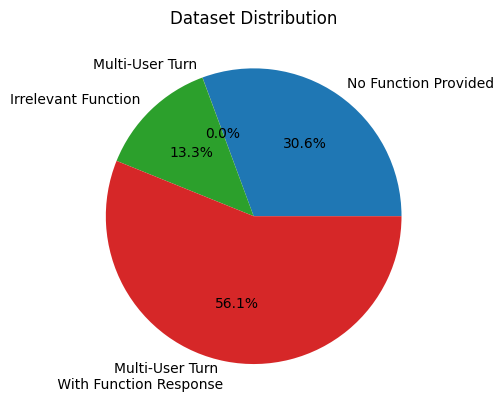

In [95]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['No Function Provided', 'Multi-User Turn', 'Irrelevant Function', 'Multi-User Turn \n With Function Response']
sizes = [
    len(no_function_prompt), len(function_with_multi_user_turn_prompt), len(irrelevant_function_prompt), len(with_function_response_prompt)
]

# Create the pie chart
plt.pie(sizes, labels=labels, autopct='%1.1f%%',)
plt.title("Dataset Distribution")
plt.show()

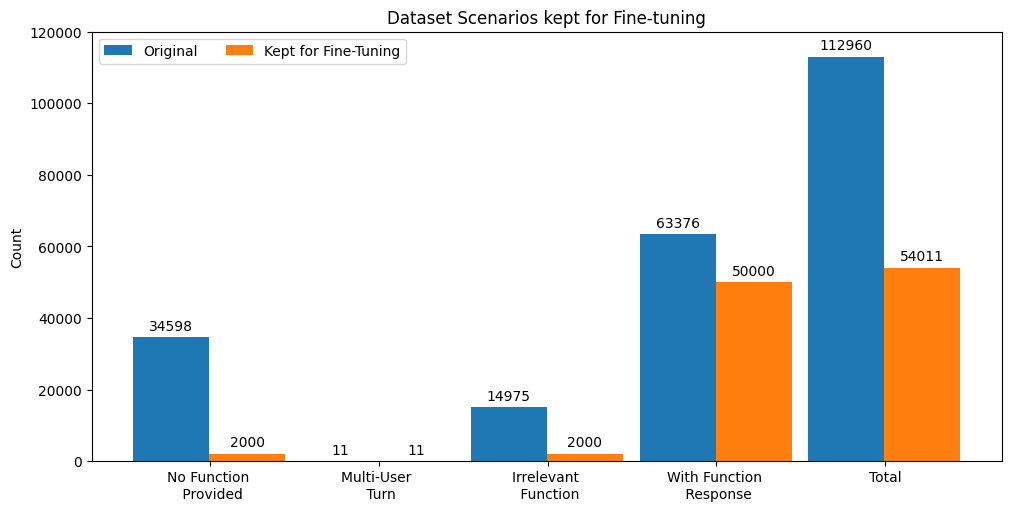

In [44]:
import matplotlib.pyplot as plt
import numpy as np

species = ('No Function \n Provided', 'Multi-User \n Turn', 'Irrelevant \n Function', 'With Function \n Response', 'Total')

penguin_means = {
    'Original': (34598, 11, 14975, 63376, 112960),
    'Kept for Fine-Tuning': (2000, 11, 2000, 50000, 54011),
}

x = np.arange(len(species))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Dataset Scenarios kept for Fine-tuning')
ax.set_xticks(x + width - 0.22, species)
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0, 120000)

plt.show()

In [62]:
print(irrelevant_function_prompt[8000])

SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "calculate_tip",
    "description": "Calculate the tip amount for a bill",
    "parameters": {
        "type": "object",
        "properties": {
            "bill_amount": {
                "type": "number",
                "description": "The total bill amount"
            },
            "tip_percentage": {
                "type": "number",
                "description": "The tip percentage to be applied"
            }
        },
        "required": [
            "bill_amount",
            "tip_percentage"
        ]
    }
}


USER: Can you please order a pizza for me?
ASSISTANT: I'm sorry, but as an AI, I don't have the capability to perform external tasks such as ordering a pizza. My current function allows me to calculate the tip amount for a bill. If you need help with that, feel free to ask. <|endoftext|>


In [70]:
[{'prompt':prompt} for prompt in no_function_prompt][101]

{'prompt': 'SYSTEM: You are a helpful assistant, with no access to external functions.\n\n\n\nUSER: How can I create an [HTML page] using C# code that displays the five basic tastes that humans can detect, including their descriptions and examples? Furthermore, can you suggest any scientific studies or research that support these findings?\nASSISTANT: I am a Function calling model, so you will have to provide me with some external function. <|endoftext|>'}

In [80]:
from datasets import DatasetDict, Dataset

no_function_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in no_function_prompt]}
)
multi_user_turn_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in function_with_multi_user_turn_prompt]}
)
irrelevant_function_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in irrelevant_function_prompt]}
)
with_function_response_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in with_function_response_prompt]}
)

In [82]:
transformed_dataset = DatasetDict(
    {
        'no_function': no_function_prompt_dataset,
        'multi_user_turn': multi_user_turn_prompt_dataset,
        'irrelevant_function': irrelevant_function_prompt_dataset,
        'with_function_response': with_function_response_prompt_dataset,
    }
)

In [83]:
transformed_dataset

DatasetDict({
    no_function: Dataset({
        features: ['prompt'],
        num_rows: 34598
    })
    multi_user_turn: Dataset({
        features: ['prompt'],
        num_rows: 11
    })
    irrelevant_function: Dataset({
        features: ['prompt'],
        num_rows: 14975
    })
    with_function_response: Dataset({
        features: ['prompt'],
        num_rows: 63376
    })
})

In [84]:
transformed_dataset.save_to_disk('./prepared_dataset')

Saving the dataset (1/1 shards): 100%|██████████| 63376/63376 [00:00<00:00, 1269858.50 examples/s]
